# Task: Forest covertypes
Natural resource managers responsible for developing ecosystem management strategies require basic descriptive information including inventory data for forested lands to support their decision-making processes.  However, managers 	generally do not have this type of data for inholdings or neighboring lands that are outside their immediate jurisdiction.  One method of obtaining this information is through the use of predictive models.



In this tutorial, you need to implement two models, `RandomForest` and `DNN`, in their corresponding functions `forest_model_predict`, `ForestCoverDNN` and `dnn_model_predict`. You should only modify the code in the “Your Code Here” area.



For more information about the task and data, please refer to the following link: https://archive.ics.uci.edu/dataset/31/covertype

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import random
import torch
import numpy as np

random_state = 0
random.seed(random_state)
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_state)


#　Data download

# Option 1: from sklearn
X, y = fetch_covtype(return_X_y=True, as_frame=True)
print(X.shape)  # (581012, 54)
print(y.shape)  # (581012,)


# Option 2: from source
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

# feature_names = [
#     "Elevation",
#     "Aspect",
#     "Slope",
#     "Horizontal_Distance_To_Hydrology",
#     "Vertical_Distance_To_Hydrology",
#     "Horizontal_Distance_To_Roadways",
#     "Hillshade_9am",
#     "Hillshade_Noon",
#     "Hillshade_3pm",
#     "Horizontal_Distance_To_Fire_Points",
# ]

# # match sklearn-style feature names
# feature_names += [f"Wilderness_Area_{i}" for i in range(4)]
# feature_names += [f"Soil_Type_{i}" for i in range(40)]

# columns = feature_names + ["Cover_Type"]

# df = pd.read_csv(url, compression="gzip", header=None, names=columns)

# X = df[feature_names]
# y = df["Cover_Type"]

# print(X.shape)  # (581012, 54)
# print(y.shape)  # (581012,)


# Option 3: through wget
# !wget -O covtype.data.gz https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz

# import pandas as pd

# feature_names = [
#     "Elevation",
#     "Aspect",
#     "Slope",
#     "Horizontal_Distance_To_Hydrology",
#     "Vertical_Distance_To_Hydrology",
#     "Horizontal_Distance_To_Roadways",
#     "Hillshade_9am",
#     "Hillshade_Noon",
#     "Hillshade_3pm",
#     "Horizontal_Distance_To_Fire_Points",
# ]
# feature_names += [f"Wilderness_Area_{i}" for i in range(4)]
# feature_names += [f"Soil_Type_{i}" for i in range(40)]

# columns = feature_names + ["Cover_Type"]

# df = pd.read_csv("covtype.data.gz", compression="gzip", header=None, names=columns)

# X = df[feature_names]
# y = df["Cover_Type"]
# print(X.shape)  # (581012, 54)
# print(y.shape)  # (581012,)

--2026-05-11 01:42:52--  https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘covtype.data.gz’

covtype.data.gz         [   <=>              ]  10.72M  21.1MB/s    in 0.5s    

2026-05-11 01:42:52 (21.1 MB/s) - ‘covtype.data.gz’ saved [11240707]

(581012, 54)
(581012,)


In [ ]:
# stratified subset for toy problem
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=50000,
    test_size=0.2,
    stratify=y,
    random_state=0
)

print(X_train.shape)
print(y_train.value_counts().sort_index())
X_train.head()

(50000, 54)
Cover_Type
1    18230
2    24380
3     3077
4      236
5      817
6     1495
7     1765
Name: count, dtype: int64


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
498245,2750,77,11,30,1,1461,234,220,117,1101,...,0,0,0,0,0,0,0,0,0,0
222957,2564,252,26,134,46,949,151,246,226,1734,...,0,0,1,0,0,0,0,0,0,0
376213,3274,14,15,210,51,3181,204,207,137,3214,...,0,0,0,0,0,0,0,0,0,0
548947,2892,126,36,661,115,4272,252,191,0,1624,...,0,0,0,0,0,0,0,0,0,0
130553,2916,315,16,150,38,3156,176,226,189,1933,...,0,0,0,0,0,0,0,0,0,0


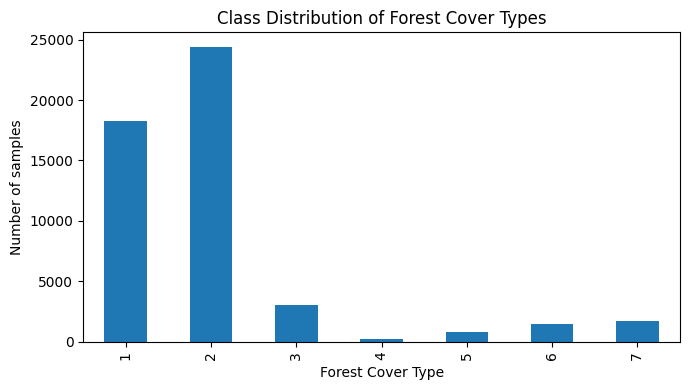

<Figure size 800x500 with 0 Axes>

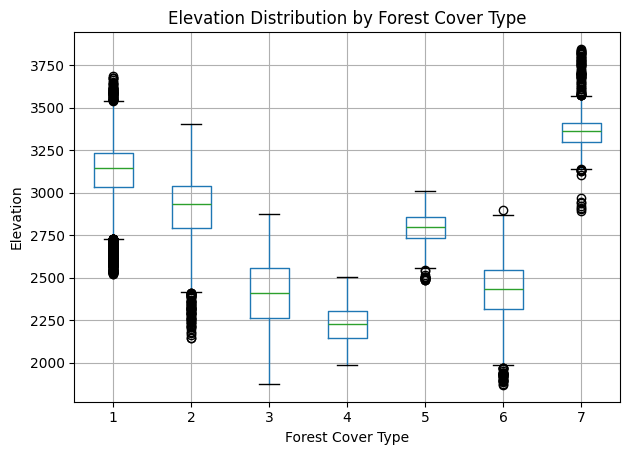

<Figure size 800x500 with 0 Axes>

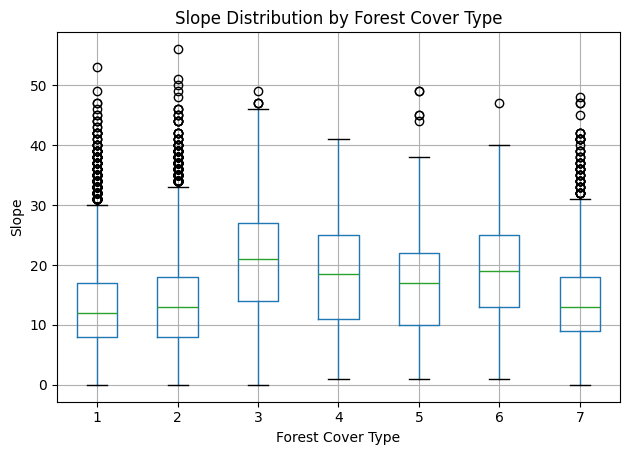

In [ ]:
X_train_vis = X_train.copy()
X_train_vis["Cover_Type"] = y_train.values

# -------------------------
# Class distribution
# -------------------------
plt.figure(figsize=(7, 4))
X_train_vis["Cover_Type"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Forest Cover Type")
plt.ylabel("Number of samples")
plt.title("Class Distribution of Forest Cover Types")
plt.tight_layout()
plt.show()


# -------------------------
# Elevation by cover type
# -------------------------
plt.figure(figsize=(8, 5))
X_train_vis.boxplot(column="Elevation", by="Cover_Type")
plt.xlabel("Forest Cover Type")
plt.ylabel("Elevation")
plt.title("Elevation Distribution by Forest Cover Type")
plt.suptitle("")
plt.tight_layout()
plt.show()


# -------------------------
# Slope by cover type
# -------------------------
plt.figure(figsize=(8, 5))
X_train_vis.boxplot(column="Slope", by="Cover_Type")
plt.xlabel("Forest Cover Type")
plt.ylabel("Slope")
plt.title("Slope Distribution by Forest Cover Type")
plt.suptitle("")
plt.tight_layout()
plt.show()


## Preprocessing step (Optional)

In [ ]:
def preprocess_features(
    X_train,
    X_test,
    y_train,
    y_test,
):
    """
    Feature engineering + compatibility checks.

    This function should be called after train/test split
    and before model training.

    Parameters
    ----------
    X_train, X_test : pandas DataFrame
    y_train, y_test : pandas Series or numpy array


    Returns
    -------
    X_train_processed, X_test_processed, y_train_processed, y_test_processed
    """
    ############## Your Code Here ##############
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()
    y_train_processed = y_train.copy()
    y_test_processed = y_test.copy()

    ###############################################
    assert isinstance(X_train_processed, pd.DataFrame), "X_train must be a pandas DataFrame."
    assert isinstance(X_test_processed, pd.DataFrame), "X_test must be a pandas DataFrame."

    assert list(X_train_processed.columns) == list(X_test_processed.columns), (
        "X_train and X_test must have the same columns in the same order "
        "before preprocessing."
    )
    assert len(X_train_processed) == len(y_train_processed), "X_train and y_train must have the same number of rows."
    assert len(X_test_processed) == len(y_test_processed), "X_test and y_test must have the same number of rows."

    return X_train_processed, X_test_processed, y_train_processed, y_test_processed


X_train, X_test, y_train, y_test = preprocess_features(X_train, X_test, y_train, y_test)

## 1. Random Forest
Check out the function usage here: [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)

In [ ]:
def forest_model_predict(X_train, y_train, X_test):
    """
    Student model function.

    Input
    -----
    X_train : training features
    y_train : training labels
    X_test  : testing features

    Output
    ------
    y_pred : predicted labels for X_test
    """

    ############## Your Code Here ##############
    model = None

    ###############################################

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return y_pred, model

In [ ]:
def evaluate_forest_cover_model(
    model_predict_fn,
    X_train,
    y_train,
    X_test,
    y_test,
    title="Forest Cover Type Evaluation",
):
    """
    Evaluate a model function on the Forest Cover Type task.

    Parameters
    ----------
    model_predict_fn : function
        A function with the following format:

        y_pred = model_predict_fn(X_train, y_train, X_test)

    X_train, y_train : training data
    X_test, y_test   : testing data
    title            : title for plots

    Returns
    -------
    results : dict
        Dictionary containing accuracy, macro F1, weighted F1,
        classification report, and confusion matrix.
    """

    # -------------------------
    # Run model
    # -------------------------
    y_pred, model = model_predict_fn(X_train, y_train, X_test)

    # -------------------------
    # Compute metrics
    # -------------------------
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    report_dict = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    report_text = classification_report(
        y_test,
        y_pred,
        zero_division=0,
    )

    cm = confusion_matrix(y_test, y_pred, labels=np.arange(1, 8))

    print("=" * 60)
    print(title)
    print("=" * 60)
    print(f"Accuracy    : {acc:.4f}")
    print(f"Macro F1    : {macro_f1:.4f}")
    print(f"Weighted F1 : {weighted_f1:.4f}")
    print()
    print(report_text)

    # -------------------------
    # Visualization 1:
    # Confusion matrix
    # -------------------------
    plt.figure(figsize=(8, 7))

    display_labels = np.arange(1, 8)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels,
    )

    disp.plot(
        values_format="d",
        xticks_rotation=45,
    )

    plt.title(f"{title}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Visualization 2:
    # Per-class F1 score
    # -------------------------
    per_class_f1 = []

    for class_id in range(1, 8):
        class_key = str(class_id)
        if class_key in report_dict:
            per_class_f1.append(report_dict[class_key]["f1-score"])
        else:
            per_class_f1.append(0.0)

    plt.figure(figsize=(9, 5))

    x_labels = [str(i) for i in range(1, 8)]

    plt.bar(x_labels, per_class_f1)
    plt.xlabel("Forest Cover Type")
    plt.ylabel("F1 Score")
    plt.title(f"{title}: Per-Class F1 Score")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()


    # -------------------------
    # Visualization 3:
    # Feature importance
    # -------------------------
    feature_names = X_train.columns.tolist()
    importances = pd.Series(
        model.feature_importances_,
        index=feature_names,
    ).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind="barh")
    plt.xlabel("Feature Importance")
    plt.title(f"{title}: Top 15 Feature Importances")
    plt.tight_layout()
    plt.show()


    results = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "classification_report": report_dict,
        "confusion_matrix": cm,
        "y_pred": y_pred,
    }

    return results

Random Forest on Forest Cover Type
Accuracy    : 0.8845
Macro F1    : 0.8155
Weighted F1 : 0.8828

              precision    recall  f1-score   support

           1       0.89      0.86      0.88     42368
           2       0.88      0.93      0.90     56660
           3       0.86      0.90      0.88      7151
           4       0.86      0.73      0.79       550
           5       0.90      0.45      0.60      1899
           6       0.83      0.70      0.76      3473
           7       0.95      0.84      0.90      4102

    accuracy                           0.88    116203
   macro avg       0.88      0.77      0.82    116203
weighted avg       0.89      0.88      0.88    116203



<Figure size 800x700 with 0 Axes>

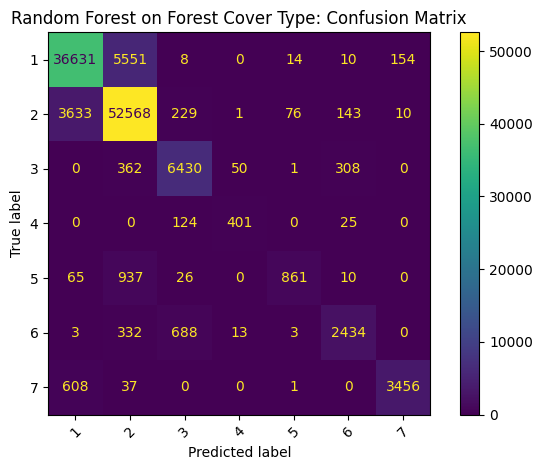

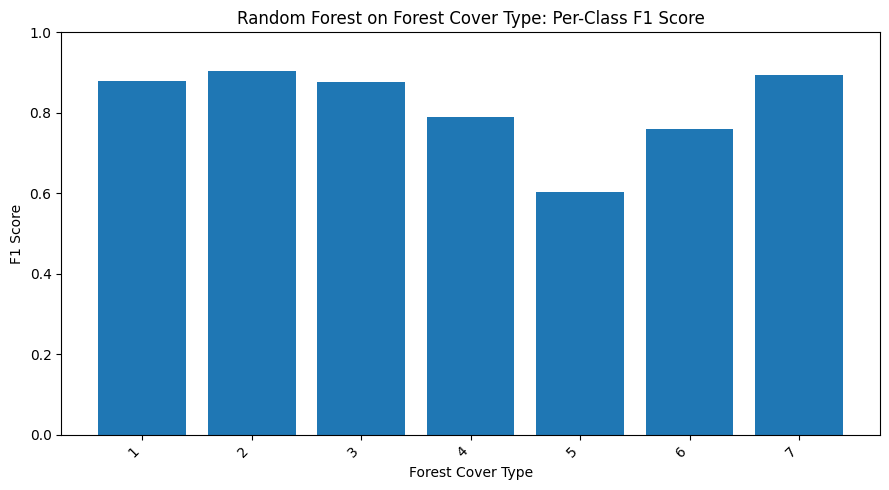

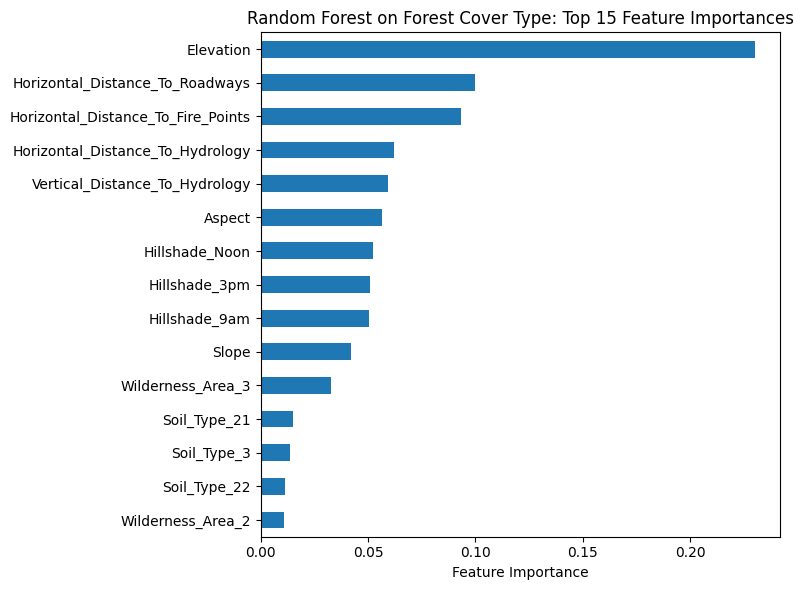

In [ ]:
results = evaluate_forest_cover_model(
    model_predict_fn=forest_model_predict,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    title="Random Forest on Forest Cover Type",
)

## 2. Deep Neural Network
Check out the Pytorch tutorial for creating models: [Learn the Basics](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)

In [ ]:
class ForestCoverDNN(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes=7,
    ):
        super().__init__()

        layers = []

        ############## Your Code Here ##############

        # Hint: Append neural network layers to layers variable. A common DNN structure is: Linear → ReLU → BatchNorm1d → Dropout → Linear -> ...
        # The first argument in the first linear layer should be input_dim, and the last argument in the last linear layer must match output_dim (i.e. 7).


        ###############################################

        assert layers != [], "Please write your model code here."

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

Epoch [01/30] Train Loss: 0.8775 | Val Loss: 0.7564 | Val Acc: 0.6802
Epoch [02/30] Train Loss: 0.8089 | Val Loss: 0.7588 | Val Acc: 0.7038
Epoch [03/30] Train Loss: 0.8058 | Val Loss: 0.7650 | Val Acc: 0.6922
Epoch [04/30] Train Loss: 0.8087 | Val Loss: 0.7608 | Val Acc: 0.6800
Epoch [05/30] Train Loss: 0.8091 | Val Loss: 0.7529 | Val Acc: 0.6655
Epoch [06/30] Train Loss: 0.8122 | Val Loss: 0.8352 | Val Acc: 0.6484
Epoch [07/30] Train Loss: 0.8100 | Val Loss: 0.7677 | Val Acc: 0.6952
Epoch [08/30] Train Loss: 0.8130 | Val Loss: 0.8168 | Val Acc: 0.6552
Epoch [09/30] Train Loss: 0.8155 | Val Loss: 0.7826 | Val Acc: 0.6643
Epoch [10/30] Train Loss: 0.8202 | Val Loss: 1.1443 | Val Acc: 0.5606
Epoch [11/30] Train Loss: 0.8244 | Val Loss: 0.8006 | Val Acc: 0.6544
Epoch [12/30] Train Loss: 0.8042 | Val Loss: 0.7794 | Val Acc: 0.6850
Epoch [13/30] Train Loss: 0.8183 | Val Loss: 0.7912 | Val Acc: 0.6867
Epoch [14/30] Train Loss: 0.8197 | Val Loss: 0.7900 | Val Acc: 0.6611
Epoch [15/30] Train 

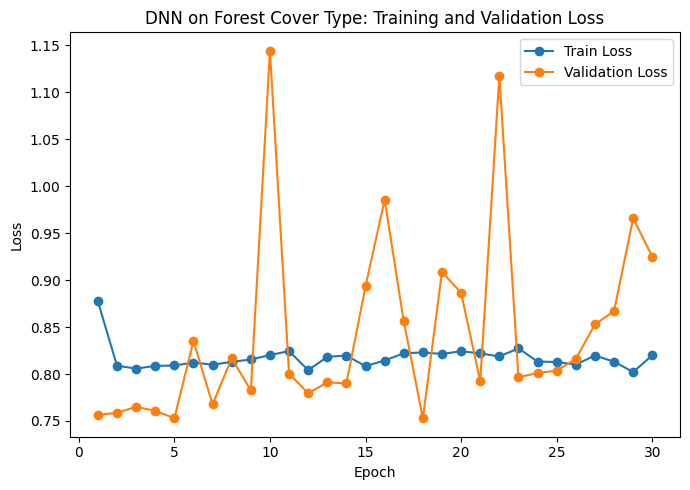

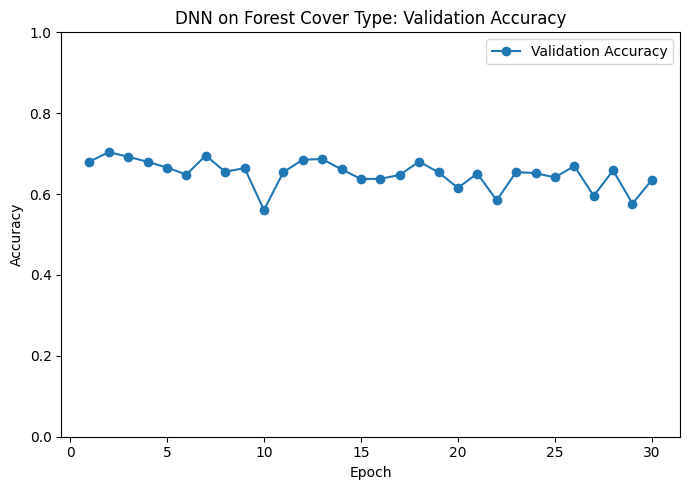

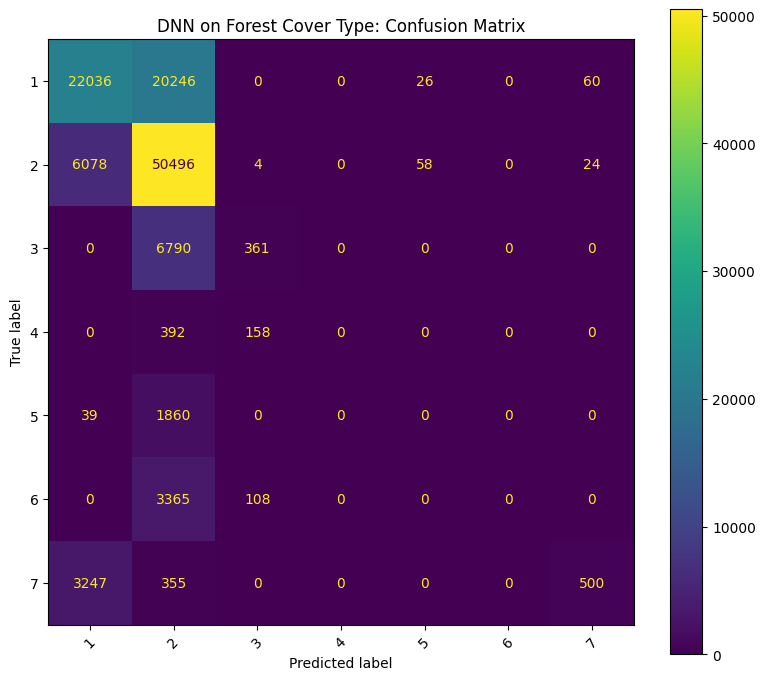

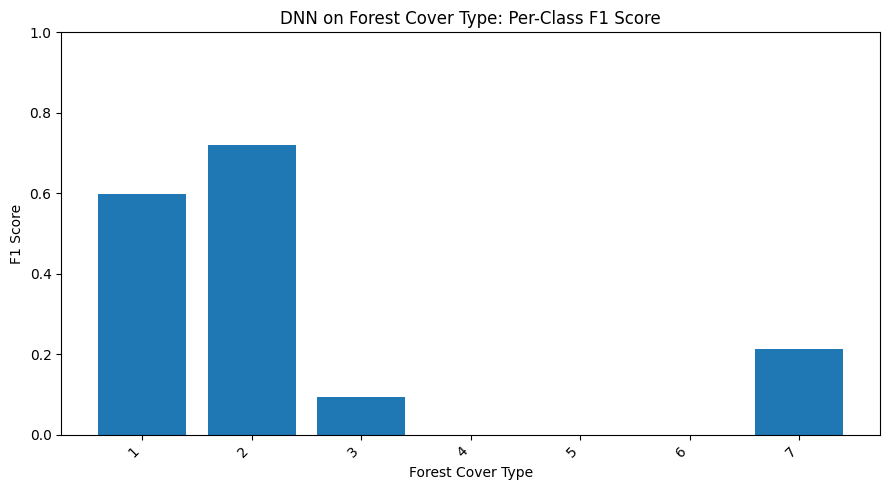

In [ ]:
def dnn_model_predict(
    X_train,
    y_train,
    X_test,
    batch_size=256,
    val_size=0.2,
    device=None,
):
    """
    DNN model function.

    Input
    -----
    X_train : training features
    y_train : training labels, original labels are 1 to 7
    X_test  : testing features

    Output
    ------
    y_pred : predicted labels for X_test, returned as 1 to 7
    info   : dictionary containing training history
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # -------------------------
    # Convert pandas to numpy
    # -------------------------
    X_train_np = np.asarray(X_train, dtype=np.float32)
    X_test_np = np.asarray(X_test, dtype=np.float32)

    y_train_np = np.asarray(y_train, dtype=np.int64)

    # Original labels are 1, 2, ..., 7
    # CrossEntropyLoss needs labels 0, 1, ..., 6
    y_train_np_zero_based = y_train_np - 1

    # -------------------------
    # Split training data into train / validation
    # -------------------------
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_np,
        y_train_np_zero_based,
        test_size=val_size,
        stratify=y_train_np_zero_based,
        random_state=random_state,
    )

    # -------------------------
    # Standardize features
    # -------------------------
    scaler = StandardScaler()

    X_tr = scaler.fit_transform(X_tr).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)
    X_test_scaled = scaler.transform(X_test_np).astype(np.float32)

    # -------------------------
    # Create DataLoaders
    # -------------------------
    train_dataset = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long),
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    # -------------------------
    # Build model
    # -------------------------
    input_dim = X_train_np.shape[1]
    num_classes = 7

    model = ForestCoverDNN(
        input_dim=input_dim,
        num_classes=num_classes,
    ).to(device)



    ############## Your Code Here ##############
    epochs=None
    criterion = None
    optimizer = None
    ################################################

    assert epochs is not None, "epochs should not be None"
    assert criterion is not None, "Please implement a criterion"
    assert optimizer is not None, "Please implement a optimizer"


    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    # -------------------------
    # Training loop
    # -------------------------
    for epoch in range(epochs):
        model.train()

        total_train_loss = 0.0
        total_train_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            batch_size_now = xb.size(0)
            total_train_loss += loss.item() * batch_size_now
            total_train_samples += batch_size_now

        avg_train_loss = total_train_loss / total_train_samples

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_val_loss = 0.0
        total_val_samples = 0
        correct = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                logits = model(xb)
                loss = criterion(logits, yb)

                preds = torch.argmax(logits, dim=1)

                batch_size_now = xb.size(0)
                total_val_loss += loss.item() * batch_size_now
                total_val_samples += batch_size_now
                correct += (preds == yb).sum().item()

        avg_val_loss = total_val_loss / total_val_samples
        val_accuracy = correct / total_val_samples

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch [{epoch + 1:02d}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    # -------------------------
    # Predict on test set
    # -------------------------
    model.eval()

    X_test_tensor = torch.tensor(
        X_test_scaled,
        dtype=torch.float32,
    ).to(device)

    with torch.no_grad():
        logits = model(X_test_tensor)
        y_pred_zero_based = torch.argmax(logits, dim=1).cpu().numpy()

    # Convert labels back from 0-6 to 1-7
    y_pred = y_pred_zero_based + 1

    info = {
        "model": model,
        "scaler": scaler,
        "history": history,
        "device": device,
    }

    return y_pred, info


# ============================================================
# Evaluation + visualization function for DNN
# ============================================================

def evaluate_dnn_forest_cover_model(
    model_predict_fn,
    X_train,
    y_train,
    X_test,
    y_test,
    title="DNN on Forest Cover Type",
):
    """
    Evaluate a DNN model function on the Forest Cover Type task.

    The model function should return either:

        y_pred

    or:

        y_pred, info

    where info may contain training history.
    """

    # -------------------------
    # Run model function
    # -------------------------
    output = model_predict_fn(X_train, y_train, X_test)

    if isinstance(output, tuple):
        y_pred, info = output
    else:
        y_pred = output
        info = {}

    # -------------------------
    # Compute metrics
    # -------------------------
    acc = accuracy_score(y_test, y_pred)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    report_dict = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    report_text = classification_report(
        y_test,
        y_pred,
        zero_division=0,
    )

    labels = np.arange(1, 8)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels,
    )

    print("=" * 70)
    print(title)
    print("=" * 70)
    print(f"Accuracy    : {acc:.4f}")
    print(f"Macro F1    : {macro_f1:.4f}")
    print(f"Weighted F1 : {weighted_f1:.4f}")
    print()
    print(report_text)

    # -------------------------
    # Visualization 1:
    # Training curves
    # -------------------------
    history = info.get("history", None)

    if history is not None:
        epochs = np.arange(1, len(history["train_loss"]) + 1)

        plt.figure(figsize=(7, 5))
        plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
        plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{title}: Training and Validation Loss")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"{title}: Validation Accuracy")
        plt.ylim(0, 1.0)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # -------------------------
    # Visualization 2:
    # Confusion matrix
    # -------------------------
    display_labels = labels

    fig, ax = plt.subplots(figsize=(8, 7))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels,
    )

    disp.plot(
        ax=ax,
        values_format="d",
        xticks_rotation=45,
        colorbar=True,
    )

    plt.title(f"{title}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Visualization 3:
    # Per-class F1 score
    # -------------------------
    per_class_f1 = []

    for class_id in labels:
        class_key = str(class_id)

        if class_key in report_dict:
            per_class_f1.append(report_dict[class_key]["f1-score"])
        else:
            per_class_f1.append(0.0)

    x_labels = [str(i) for i in labels]

    plt.figure(figsize=(9, 5))
    plt.bar(x_labels, per_class_f1)
    plt.xlabel("Forest Cover Type")
    plt.ylabel("F1 Score")
    plt.title(f"{title}: Per-Class F1 Score")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()


results = evaluate_dnn_forest_cover_model(
    model_predict_fn=dnn_model_predict,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    title="DNN on Forest Cover Type",
)